# Model 1: Baseline Merton (Diffusion-Only)

**Model:** Standard Merton (1974) structural credit model with smooth diffusion.

**Specification:**
```
dA = μA·dt + σA·dW
d₂ = [ln(A/B) + (r - σ²/2)T] / (σ√T)
PD = N(-d₂)
```

**Validation regression:**
```
Δln(CDS_it) = α_i + γ_t + β·ΔPD_it + ε_it
```

In [51]:
import pandas as pd
import numpy as np
from scipy.stats import norm, linregress
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [52]:
# =============================================================================
# CONFIGURATION
# =============================================================================
PANEL_PATH = "data/processed/merton_panel.csv"

# Model parameters
T = 5.0  # Time horizon (1 year)

---
## 1. Load Panel

In [57]:
panel = pd.read_csv(PANEL_PATH, parse_dates=['date'])

print(f"Panel: {len(panel)} obs, {panel['country'].nunique()} countries")
print(f"Date range: {panel['date'].min().date()} to {panel['date'].max().date()}")
print(f"\nColumns: {list(panel.columns)}")
print(f"\nGroup distribution:")
print(panel.groupby('group')['country'].nunique())

Panel: 10961 obs, 20 countries
Date range: 2014-01-03 to 2024-12-27

Columns: ['country', 'country_clean', 'group', 'date', 'msci_index', 'msci_ret_weekly', 'msci_vol_52w', 'n_trading_days', 'debt_st', 'debt_lt', 'default_barrier', 'cds_spread', 'rf']

Group distribution:
group
control         8
oil_exporter    6
other           6
Name: country, dtype: int64


---
## 2. Scale Asset Value

MSCI index levels are arbitrary. We scale per country so dynamics are preserved but levels are comparable to debt barrier.

In [58]:
# Compute scaling factor: mean(A) = 1.5 × mean(B)
# Rationale: Sovereigns typically have assets > liabilities
TARGET_RATIO = 2

scale_factors = panel.groupby('country').apply(
    lambda g: TARGET_RATIO * g['default_barrier'].mean() / g['msci_index'].mean()
).reset_index()
scale_factors.columns = ['country', 'scale_factor']

# Merge and compute scaled asset
panel = panel.merge(scale_factors, on='country')
panel['A'] = panel['msci_index'] * panel['scale_factor']

print("Scaled asset (A) vs default barrier (B):")
print(panel.groupby('country')[['A', 'default_barrier']].mean().head(10))

Scaled asset (A) vs default barrier (B):
                      A  default_barrier
country                                 
Brazil     1.542985e+11     7.714923e+10
Chile      2.047777e+10     1.023888e+10
China      2.597765e+11     1.298883e+11
Colombia   4.978763e+10     2.489382e+10
Czechia    3.938495e+10     1.969247e+10
Egypt      4.541564e+10     2.270782e+10
Greece     2.902280e+11     1.451140e+11
Hungary    5.659645e+10     2.829822e+10
India      1.087459e+11     5.437294e+10
Indonesia  1.610499e+11     8.052495e+10


---
## 3. Compute Distance-to-Default and PD

In [59]:
def compute_d2(A, B, sigma, r, T=1.0):
    """
    Merton distance-to-default.
    
    d₂ = [ln(A/B) + (r - σ²/2)T] / (σ√T)
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        d2 = (np.log(A / B) + (r - sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return d2


def compute_pd(d2):
    """Risk-neutral default probability: PD = N(-d₂)"""
    return norm.cdf(-d2)

In [60]:
# Compute d₂ and PD
panel['d2'] = compute_d2(
    A=panel['A'],
    B=panel['default_barrier'],
    sigma=panel['msci_vol_52w'],
    r=panel['rf'],
    T=T
)

panel['pd'] = compute_pd(panel['d2'])

print("Distance-to-Default (d₂):")
print(panel['d2'].describe())

print("\nDefault Probability (PD):")
print(panel['pd'].describe())

Distance-to-Default (d₂):
count    10961.000000
mean         1.528474
std          1.276646
min         -1.107902
25%          0.601151
50%          1.402762
75%          2.327375
max          7.416212
Name: d2, dtype: float64

Default Probability (PD):
count    1.096100e+04
mean     1.721436e-01
std      2.033283e-01
min      6.025859e-14
25%      9.972656e-03
50%      8.034397e-02
75%      2.738696e-01
max      8.660480e-01
Name: pd, dtype: float64


In [61]:
# Check for issues
print(f"\nInvalid d₂ values:")
print(f"  NaN: {panel['d2'].isna().sum()}")
print(f"  Inf: {np.isinf(panel['d2']).sum()}")
print(f"  Negative: {(panel['d2'] < 0).sum()}")

# Drop invalid
panel = panel.replace([np.inf, -np.inf], np.nan)
panel = panel.dropna(subset=['d2', 'pd'])
print(f"\nAfter cleaning: {len(panel)} obs")


Invalid d₂ values:
  NaN: 0
  Inf: 0
  Negative: 1289

After cleaning: 10961 obs


---
## 4. Compute Changes for Regression

In [62]:
# Sort and compute changes
panel = panel.sort_values(['country', 'date'])

# Δln(CDS)
panel['ln_cds'] = np.log(panel['cds_spread'])
panel['d_ln_cds'] = panel.groupby('country')['ln_cds'].diff()

# ΔPD
panel['d_pd'] = panel.groupby('country')['pd'].diff()

# Time fixed effect
panel['ym'] = panel['date'].dt.to_period('M').astype(str)

# Clean regression data
reg_data = panel.dropna(subset=['d_ln_cds', 'd_pd'])
reg_data = reg_data.replace([np.inf, -np.inf], np.nan).dropna(subset=['d_ln_cds', 'd_pd'])

print(f"Regression sample: {len(reg_data)} obs, {reg_data['country'].nunique()} countries")

Regression sample: 10941 obs, 20 countries


---
## 5. Main Regression: Full Sample

In [63]:
# Regression: Δln(CDS) = α_i + γ_t + β·ΔPD + ε
model = smf.ols('d_ln_cds ~ d_pd + C(country) + C(ym)', data=reg_data).fit()

print("="*60)
print("BASELINE MERTON MODEL: FULL SAMPLE")
print("="*60)
print(f"β (ΔPD):   {model.params['d_pd']:.4f}")
print(f"t-stat:    {model.tvalues['d_pd']:.2f}")
print(f"p-value:   {model.pvalues['d_pd']:.4f}")
print(f"R²:        {model.rsquared:.4f}")
print(f"N:         {int(model.nobs)}")

BASELINE MERTON MODEL: FULL SAMPLE
β (ΔPD):   0.7929
t-stat:    24.95
p-value:   0.0000
R²:        0.1350
N:         10941


---
## 6. Regression by Group: Oil Exporters vs Controls

In [64]:
# Split samples
oil_sample = reg_data[reg_data['group'] == 'oil_exporter']
control_sample = reg_data[reg_data['group'] == 'control']

print(f"Oil exporters: {oil_sample['country'].nunique()} countries, {len(oil_sample)} obs")
print(f"Controls: {control_sample['country'].nunique()} countries, {len(control_sample)} obs")

Oil exporters: 6 countries, 3126 obs
Controls: 8 countries, 4441 obs


In [65]:
# Run regressions by group
model_oil = smf.ols('d_ln_cds ~ d_pd + C(country) + C(ym)', data=oil_sample).fit()
model_ctrl = smf.ols('d_ln_cds ~ d_pd + C(country) + C(ym)', data=control_sample).fit()

print("="*70)
print("COMPARISON: OIL EXPORTERS vs CONTROLS")
print("="*70)
print(f"{'Metric':<20} {'Oil Exporters':>20} {'Controls':>20}")
print("-"*70)
print(f"{'β (ΔPD)':<20} {model_oil.params['d_pd']:>20.4f} {model_ctrl.params['d_pd']:>20.4f}")
print(f"{'t-stat':<20} {model_oil.tvalues['d_pd']:>20.2f} {model_ctrl.tvalues['d_pd']:>20.2f}")
print(f"{'R²':<20} {model_oil.rsquared:>20.4f} {model_ctrl.rsquared:>20.4f}")
print(f"{'N':<20} {int(model_oil.nobs):>20} {int(model_ctrl.nobs):>20}")
print("-"*70)
print(f"{'R² Difference':<20} {model_oil.rsquared - model_ctrl.rsquared:>20.4f}")

COMPARISON: OIL EXPORTERS vs CONTROLS
Metric                      Oil Exporters             Controls
----------------------------------------------------------------------
β (ΔPD)                            0.7701               0.9921
t-stat                              14.74                21.89
R²                                 0.2018               0.2297
N                                    3126                 4441
----------------------------------------------------------------------
R² Difference                     -0.0279


---
## 7. Country-Level Results

In [66]:
# R² and β by country (simple OLS)
country_results = []

for country in reg_data['country'].unique():
    df = reg_data[reg_data['country'] == country]
    if len(df) < 50:
        continue
    
    slope, intercept, r, p, se = linregress(df['d_pd'], df['d_ln_cds'])
    
    country_results.append({
        'country': country,
        'group': df['group'].iloc[0],
        'beta': slope,
        'r_squared': r**2,
        'p_value': p,
        'n_obs': len(df)
    })

country_df = pd.DataFrame(country_results).sort_values('r_squared', ascending=False)

print("Country-level results (simple OLS):")
print(country_df.to_string(index=False))

Country-level results (simple OLS):
     country        group      beta  r_squared      p_value  n_obs
      Turkey      control  1.626652   0.352878 6.093778e-56    573
South Africa      control  1.498729   0.294269 3.747861e-45    573
      Mexico oil_exporter  2.147001   0.293410 5.310299e-45    573
      Brazil oil_exporter  1.272039   0.236210 2.651185e-35    573
    Colombia oil_exporter  1.406734   0.225333 1.537565e-33    573
    Malaysia oil_exporter  5.472180   0.171466 3.037713e-19    430
   Indonesia      control  1.470130   0.170219 5.865764e-25    573
     Hungary        other  0.759427   0.159305 2.527686e-23    573
 South Korea      control  1.693849   0.155127 1.054449e-22    573
        Peru        other  1.278555   0.124952 2.630496e-18    573
    Thailand      control  1.009610   0.101364 5.783198e-15    573
Saudi Arabia oil_exporter  1.845609   0.096272 1.827438e-10    404
 Philippines      control  0.889819   0.057697 5.789129e-09    573
       Chile      control 

In [67]:
# Summary by group
print("\nSummary by group:")
print(country_df.groupby('group')[['beta', 'r_squared']].agg(['mean', 'median']).round(4))


Summary by group:
                beta         r_squared        
                mean  median      mean  median
group                                         
control       1.1357  1.2399    0.1490  0.1282
oil_exporter  2.0227  1.6262    0.1705  0.1984
other         0.5601  0.5663    0.0597  0.0312


---
## 8. Visualization

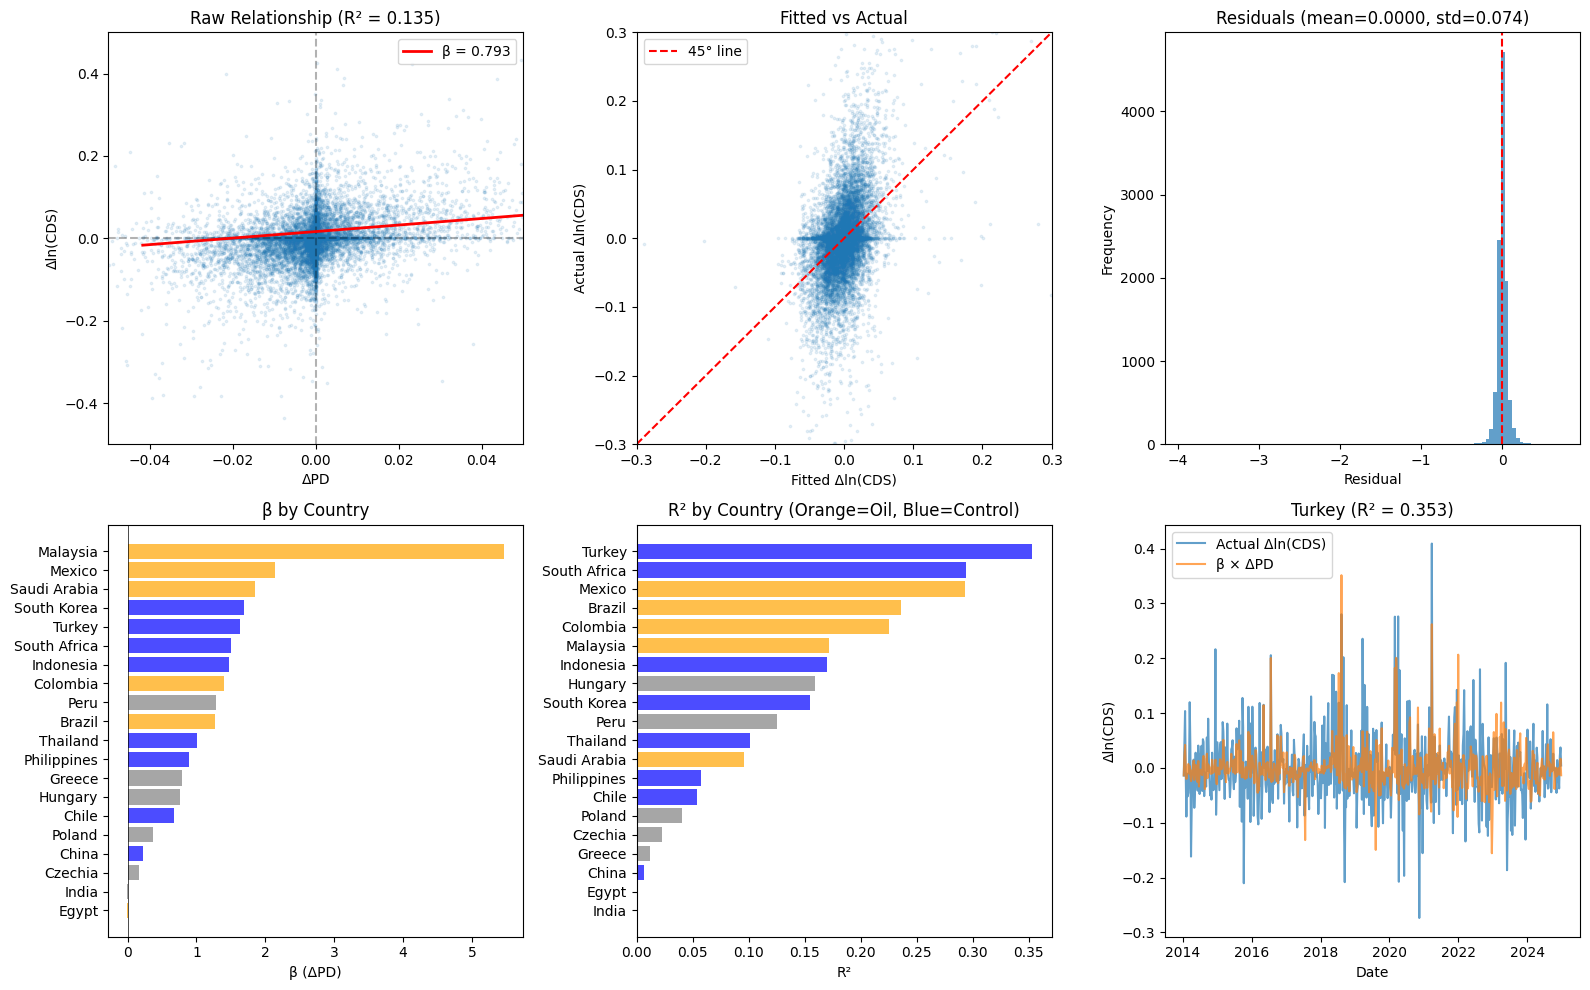

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Scatter: ΔPD vs Δln(CDS)
ax = axes[0, 0]
ax.scatter(reg_data['d_pd'], reg_data['d_ln_cds'], alpha=0.1, s=3)
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.axvline(0, color='k', linestyle='--', alpha=0.3)
# Regression line
x_line = np.linspace(reg_data['d_pd'].quantile(0.01), reg_data['d_pd'].quantile(0.99), 100)
y_line = model.params['Intercept'] + model.params['d_pd'] * x_line
ax.plot(x_line, y_line, 'r-', linewidth=2, label=f'β = {model.params["d_pd"]:.3f}')
ax.set_xlabel('ΔPD')
ax.set_ylabel('Δln(CDS)')
ax.set_title(f'Raw Relationship (R² = {model.rsquared:.3f})')
ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-0.5, 0.5)
ax.legend()

# 2. Fitted vs Actual
ax = axes[0, 1]
fitted = model.fittedvalues
actual = reg_data.loc[fitted.index, 'd_ln_cds']
ax.scatter(fitted, actual, alpha=0.1, s=3)
lim = 0.3
ax.plot([-lim, lim], [-lim, lim], 'r--', label='45° line')
ax.set_xlabel('Fitted Δln(CDS)')
ax.set_ylabel('Actual Δln(CDS)')
ax.set_title('Fitted vs Actual')
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.legend()

# 3. Residuals
ax = axes[0, 2]
residuals = model.resid
ax.hist(residuals, bins=100, edgecolor='none', alpha=0.7)
ax.axvline(0, color='r', linestyle='--')
ax.set_xlabel('Residual')
ax.set_ylabel('Frequency')
ax.set_title(f'Residuals (mean={residuals.mean():.4f}, std={residuals.std():.3f})')

# 4. β by country
ax = axes[1, 0]
country_df_sorted = country_df.sort_values('beta', ascending=True)
colors = ['orange' if g == 'oil_exporter' else ('blue' if g == 'control' else 'gray') 
          for g in country_df_sorted['group']]
ax.barh(country_df_sorted['country'], country_df_sorted['beta'], color=colors, alpha=0.7)
ax.axvline(0, color='k', linestyle='-', linewidth=0.5)
ax.set_xlabel('β (ΔPD)')
ax.set_title('β by Country')

# 5. R² by country
ax = axes[1, 1]
country_df_r2 = country_df.sort_values('r_squared', ascending=True)
colors = ['orange' if g == 'oil_exporter' else ('blue' if g == 'control' else 'gray') 
          for g in country_df_r2['group']]
ax.barh(country_df_r2['country'], country_df_r2['r_squared'], color=colors, alpha=0.7)
ax.set_xlabel('R²')
ax.set_title('R² by Country (Orange=Oil, Blue=Control)')

# 6. Time series for top country
ax = axes[1, 2]
top_country = country_df.iloc[0]['country']
sample = reg_data[reg_data['country'] == top_country].copy()
ax.plot(sample['date'], sample['d_ln_cds'], label='Actual Δln(CDS)', alpha=0.7)
ax.plot(sample['date'], sample['d_pd'] * country_df.iloc[0]['beta'], 
        label='β × ΔPD', alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('Δln(CDS)')
ax.set_title(f'{top_country} (R² = {country_df.iloc[0]["r_squared"]:.3f})')
ax.legend()

plt.tight_layout()
plt.show()

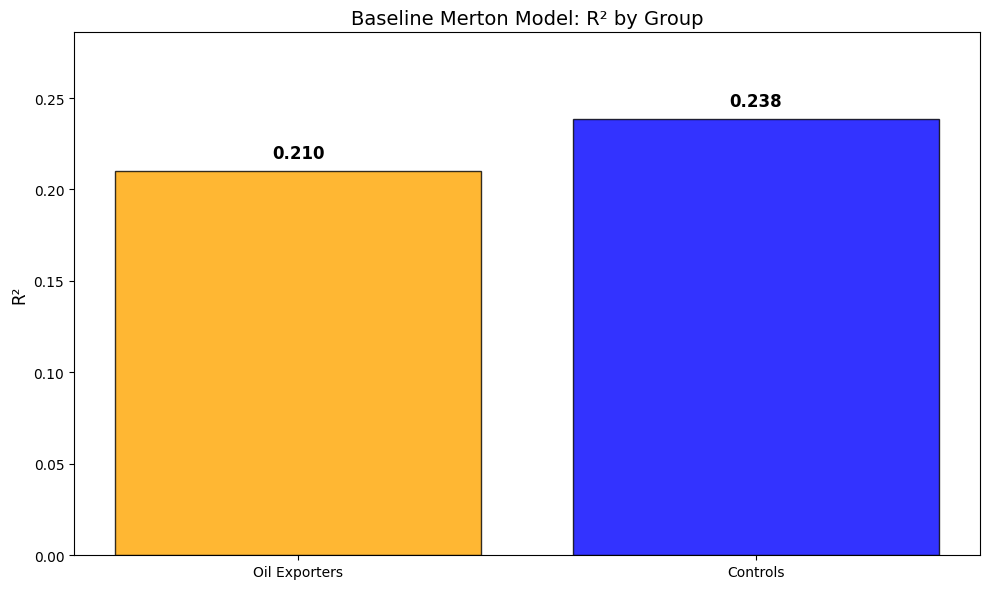

In [16]:
# R² comparison: Oil vs Control
fig, ax = plt.subplots(figsize=(10, 6))

groups = ['Oil Exporters', 'Controls']
r2_values = [model_oil.rsquared, model_ctrl.rsquared]
colors = ['orange', 'blue']

bars = ax.bar(groups, r2_values, color=colors, alpha=0.8, edgecolor='black')

# Add value labels
for bar, val in zip(bars, r2_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('R²', fontsize=12)
ax.set_title('Baseline Merton Model: R² by Group', fontsize=14)
ax.set_ylim(0, max(r2_values) * 1.2)

plt.tight_layout()
plt.show()

---
## 9. Summary

In [17]:
print("\n" + "="*70)
print("BASELINE MERTON MODEL: SUMMARY")
print("="*70)

print("\n1. MODEL SPECIFICATION")
print("   d₂ = [ln(A/B) + (r - σ²/2)T] / (σ√T)")
print("   PD = N(-d₂)")
print("   Regression: Δln(CDS) = α_i + γ_t + β·ΔPD + ε")

print("\n2. FULL SAMPLE RESULTS")
print(f"   β (ΔPD): {model.params['d_pd']:.4f} (t = {model.tvalues['d_pd']:.2f})")
print(f"   R²: {model.rsquared:.4f}")
print(f"   N: {int(model.nobs)}")

print("\n3. BY GROUP")
print(f"   Oil Exporters: R² = {model_oil.rsquared:.4f}, β = {model_oil.params['d_pd']:.4f}")
print(f"   Controls:      R² = {model_ctrl.rsquared:.4f}, β = {model_ctrl.params['d_pd']:.4f}")

print("\n4. INTERPRETATION")
print(f"   - β > 0 confirms: ↑PD → ↑CDS (correct sign)")
print(f"   - R² = {model.rsquared:.1%} of CDS variation explained by ΔPD (after FE)")
print(f"   - This baseline will be compared against jump-diffusion models")


BASELINE MERTON MODEL: SUMMARY

1. MODEL SPECIFICATION
   d₂ = [ln(A/B) + (r - σ²/2)T] / (σ√T)
   PD = N(-d₂)
   Regression: Δln(CDS) = α_i + γ_t + β·ΔPD + ε

2. FULL SAMPLE RESULTS
   β (ΔPD): 0.7024 (t = 26.31)
   R²: 0.1403
   N: 10941

3. BY GROUP
   Oil Exporters: R² = 0.2100, β = 0.6958
   Controls:      R² = 0.2383, β = 0.8769

4. INTERPRETATION
   - β > 0 confirms: ↑PD → ↑CDS (correct sign)
   - R² = 14.0% of CDS variation explained by ΔPD (after FE)
   - This baseline will be compared against jump-diffusion models


---
## 10. Save Results for Comparison

In [ ]:
# Save panel with model outputs
panel.to_csv('data/processed/model1_baseline_results.csv', index=False)
print("Saved panel with d₂ and PD to data/processed/model1_baseline_results.csv")

# Save country-level results
country_df.to_csv('data/processed/model1_country_results.csv', index=False)
print("Saved country results to data/processed/model1_country_results.csv")

In [ ]:
# Store key metrics for later comparison
baseline_metrics = {
    'model': 'Baseline Merton',
    'beta_full': model.params['d_pd'],
    'r2_full': model.rsquared,
    'beta_oil': model_oil.params['d_pd'],
    'r2_oil': model_oil.rsquared,
    'beta_control': model_ctrl.params['d_pd'],
    'r2_control': model_ctrl.rsquared,
    'n_full': int(model.nobs),
    'n_oil': int(model_oil.nobs),
    'n_control': int(model_ctrl.nobs)
}

pd.DataFrame([baseline_metrics]).to_csv('data/processed/model1_metrics.csv', index=False)
print("\nKey metrics saved for model comparison")
print(pd.DataFrame([baseline_metrics]).T)